<a href="https://colab.research.google.com/github/kamilakhtar015/Deep-Learning-Concepts/blob/main/Conditional_%CE%B2_VAE_on_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
print("Let's Implement Conditional β-VAE on MNIST dataset")

Let's Implement Conditional β-VAE on MNIST dataset


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {device}")

Using device : cuda


# Data Preparation

1- tranforms.ToTensor() - Convert images from PIL to PyTorch tensors and also scales pixels from range of [0, 255] to [0.0, 1.0]

2- tranforms.Normalize((0.5), (0.5)) - normalizes the tensor values to a range of [-1, 1] by subtracting and dividing by 0.5

In [5]:
transform = transforms.Compose([
    transforms.ToTensor()
])

# download and load the train dataset
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)

# download and load the val/test dataset
val_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
val_loader = DataLoader(dataset=val_dataset, batch_size=128, shuffle=False)

data_iter = iter(train_loader)
images, labels = next(data_iter)

print(f"Images batch shape : {images.shape}")
print(f"Lables batch shape : {labels.shape}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.44MB/s]

Images batch shape : torch.Size([128, 1, 28, 28])
Lables batch shape : torch.Size([128])


# CVAE Model Architecture

In [6]:
import torch
import torch.nn as nn

class CVAE(nn.Module):
    def __init__(self, latent_dim=2, label_dim=10, embedding_dim=16):
        super(CVAE, self).__init__()

        # The dimensionality of the latent space (z)
        self.latent_dim = latent_dim
        # The number of possible classes/labels (0-9 for MNIST).
        self.label_dim = label_dim
        # The size of the dense vector for each label.
        self.embedding_dim = embedding_dim

        # --- Layer Definitions ---
        # 1. Label Embedding layer
        # This layer turns a digit label (e.g., 5) into a 16-dimensional vector.
        self.label_embedding = nn.Embedding(self.label_dim, self.embedding_dim)

        # 2. Encoder: Compresses the input image into latent space parameters.
        # This part consists of convolutional layers.
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
        )

        # fully connected layers.
        self.encoder_fc = nn.Sequential(
            nn.Linear(128 * 7 * 7 + self.embedding_dim, 256),
            nn.ReLU()
        )

        # Two separate linear layers ("heads") to output mu and log_sigma_sq.
        # This head outputs the mean (mu) of the latent distribution.
        self.fc_mu = nn.Linear(256, self.latent_dim)
        self.fc_log_sigma_sq = nn.Linear(256, self.latent_dim)

        # 3. Decoder: Reconstructs an image from a latent vector (z) and a label.
        # This part consists of fully connected layers.
        self.decoder_fc = nn.Sequential(
            nn.Linear(self.latent_dim + self.embedding_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128 * 7 * 7),
            nn.ReLU()
        )

        # This part consists of deconvolutional (transpose convolutional) layers.
        self.decoder_deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1)
        )

        # custom weight initialization method.
        self.init_weights()

    # The init_weights method sets the initial weights of the layers.
    def init_weights(self):
        # Iterate through all the modules (layers) in the network.
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
                nn.init.normal_(m.weight, mean=0, std=0.01)  # Initialize its weights from a normal distribution with small std.
                if m.bias is not None: # If the layer has a bias, initialize it to zero.
                    nn.init.zeros_(m.bias)

        # Specifically initialize the final decoder layer's weights and bias to zero for stability.
        nn.init.zeros_(self.decoder_deconv[-1].weight)
        nn.init.zeros_(self.decoder_deconv[-1].bias)

    # The encode method defines the forward pass for the encoder part.
    def encode(self, x, y):
        embedded_label = self.label_embedding(y) # Convert the numerical label y into its 16-dimensional embedding vector.
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1) # flatten feature map into 1D vector

        # Concatenate the flattened image features and the label embedding.
        h_cat = torch.cat([h, embedded_label], dim=1)
        h_fc = self.encoder_fc(h_cat)
        mu = self.fc_mu(h_fc)
        log_sigma_sq = self.fc_log_sigma_sq(h_fc)
        return mu, log_sigma_sq

    # The reparameterize
    def reparameterize(self, mu, log_sigma_sq):
        log_sigma_sq = torch.clamp(log_sigma_sq, min=-8, max=8)
        std = torch.exp(0.5 * log_sigma_sq)
        epsilon = torch.randn_like(std)
        # Compute the latent vector z using the trick: z = mu + std * epsilon
        z = mu + std * epsilon
        return z

    # The decode method defines the forward pass for the decoder part.
    def decode(self, z, y):
        embedded_label = self.label_embedding(y)
        z_cat = torch.cat([z, embedded_label], dim=1)
        d = self.decoder_fc(z_cat)
        d = d.view(d.size(0), 128, 7, 7)
        logits = self.decoder_deconv(d)
        return logits

    # The forward method defines the full end-to-end pass through the CVAE.
    def forward(self, x, y):
        # Pass the input image and label through the encoder to get mu and log_sigma_sq.
        mu, log_sigma_sq = self.encode(x, y)
        # Sample a latent vector z from the learned distribution using the reparameterization trick.
        z = self.reparameterize(mu, log_sigma_sq)
        # Pass the latent vector z and the label through the decoder to get the reconstructed logits.
        recon_logits = self.decode(z, y)
        # final outputs of the model.
        return recon_logits, mu, log_sigma_sq

In [7]:
def loss_function(recon_logits, x, mu, log_sigma_sq, beta):
    # 1. Reconstruction Loss (BCE)
    # reduction='sum' which is equivalent to (BCE * 784).
    recon_loss = nn.functional.binary_cross_entropy_with_logits(
        recon_logits, x, reduction='sum'
    )

    # 2. KL Divergence
    # KL(q(z|x,y) || N(0,I)) = 0.5 * sum(mu^2 + sigma^2 - 1 - log(sigma^2))
    # where sigma^2 = exp(log_sigma_sq)
    kl_loss = -0.5 * torch.sum(1 + log_sigma_sq - mu.pow(2) - log_sigma_sq.exp())

    # Average losses over the batch
    batch_size = x.size(0)
    recon_loss /= batch_size
    kl_loss /= batch_size

    # 3. Total Loss
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [8]:
def train_model(beta, num_epochs=15):
    # Initialize model, optimizer, and history tracking
    model = CVAE().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=1e-4)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_recon': [], 'val_recon': [],
        'train_kl': [], 'val_kl': []
    }

    print(f"--- Training with beta = {beta} ---")

    for epoch in range(1, num_epochs + 1):
        # Training Phase
        model.train()
        train_loss, train_recon, train_kl = 0, 0, 0

        # Beta warmup schedule
        warmup_epochs = 8
        beta_eff = min(beta, beta * epoch / max(1.0, warmup_epochs))

        for batch_idx, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device), labels.to(device)

            # Forward pass
            recon_logits, mu, log_sigma_sq = model(data, labels)

            # Calculate loss
            loss, recon, kl = loss_function(recon_logits, data, mu, log_sigma_sq, beta_eff)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradient clipping
            optimizer.step()

            # Accumulate losses
            train_loss += loss.item()
            train_recon += recon.item()
            train_kl += kl.item()

        # Validation Phase
        model.eval()
        val_loss, val_recon, val_kl = 0, 0, 0
        with torch.no_grad():
            for data, labels in val_loader:
                data, labels = data.to(device), labels.to(device)
                recon_logits, mu, log_sigma_sq = model(data, labels)
                loss, recon, kl = loss_function(recon_logits, data, mu, log_sigma_sq, beta) # Use final beta for val

                val_loss += loss.item()
                val_recon += recon.item()
                val_kl += kl.item()

        # Logging
        # Calculate average losses for the epoch
        train_loss /= len(train_loader)
        train_recon /= len(train_loader)
        train_kl /= len(train_loader)

        val_loss /= len(val_loader)
        val_recon /= len(val_loader)
        val_kl /= len(val_loader)

        # Store history
        history['train_loss'].append(train_loss)
        history['train_recon'].append(train_recon)
        history['train_kl'].append(train_kl)
        history['val_loss'].append(val_loss)
        history['val_recon'].append(val_recon)
        history['val_kl'].append(val_kl)

        print(f"Epoch {epoch}/{num_epochs} | Train Loss: {train_loss:.2f} | Val Loss: {val_loss:.2f} | "
              f"Recon: {val_recon:.2f} | KL: {val_kl:.2f}")

    return model, history

# Now, we can run the training for both beta values
model_b1, history_b1 = train_model(beta=1)
model_b4, history_b4 = train_model(beta=4)

--- Training with beta = 1 ---
Epoch 1/15 | Train Loss: 202.41 | Val Loss: 156.31 | Recon: 149.37 | KL: 6.95
Epoch 2/15 | Train Loss: 147.19 | Val Loss: 148.76 | Recon: 143.02 | KL: 5.74
Epoch 3/15 | Train Loss: 141.05 | Val Loss: 142.11 | Recon: 136.50 | KL: 5.61
Epoch 4/15 | Train Loss: 137.09 | Val Loss: 137.86 | Recon: 132.76 | KL: 5.10
Epoch 5/15 | Train Loss: 135.44 | Val Loss: 136.13 | Recon: 131.26 | KL: 4.87
Epoch 6/15 | Train Loss: 134.63 | Val Loss: 135.09 | Recon: 130.48 | KL: 4.61
Epoch 7/15 | Train Loss: 134.33 | Val Loss: 135.35 | Recon: 130.76 | KL: 4.59
Epoch 8/15 | Train Loss: 134.20 | Val Loss: 134.02 | Recon: 129.42 | KL: 4.60
Epoch 9/15 | Train Loss: 133.51 | Val Loss: 133.31 | Recon: 128.82 | KL: 4.48
Epoch 10/15 | Train Loss: 132.95 | Val Loss: 133.19 | Recon: 128.54 | KL: 4.65
Epoch 11/15 | Train Loss: 132.53 | Val Loss: 132.49 | Recon: 127.92 | KL: 4.57
Epoch 12/15 | Train Loss: 132.14 | Val Loss: 132.45 | Recon: 127.97 | KL: 4.48
Epoch 13/15 | Train Loss: 131.

Displaying training curves for beta=1


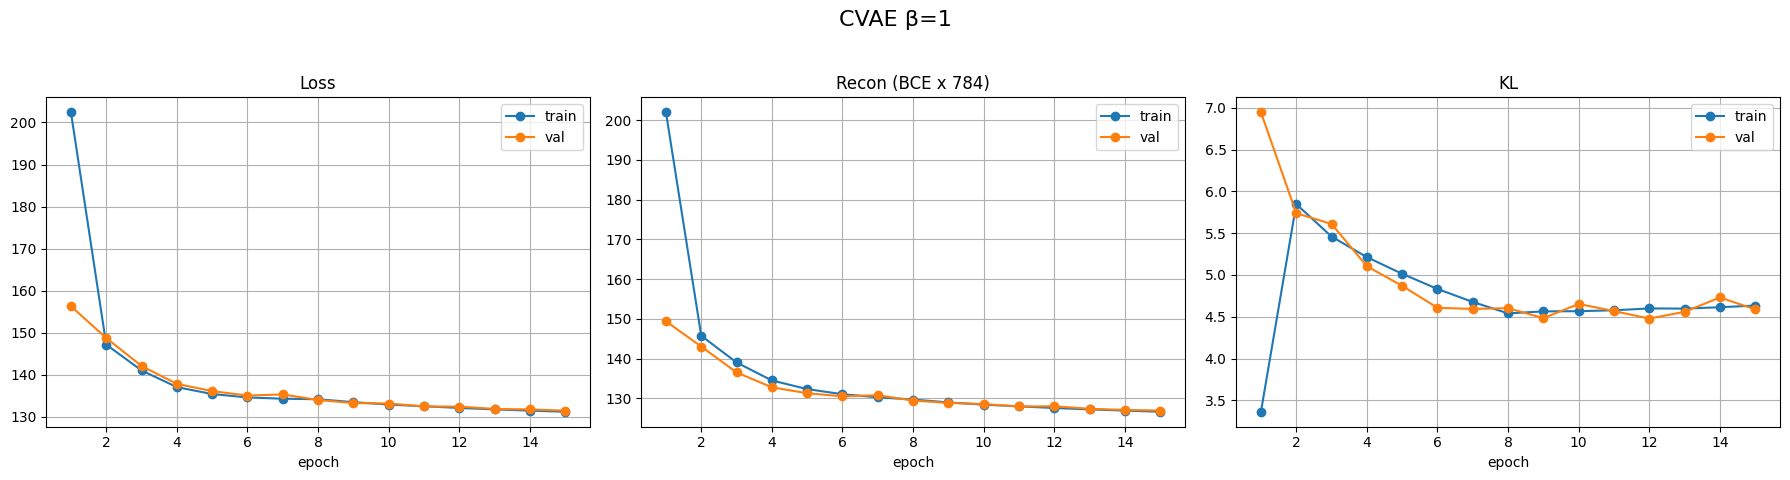


Displaying training curves for beta=4


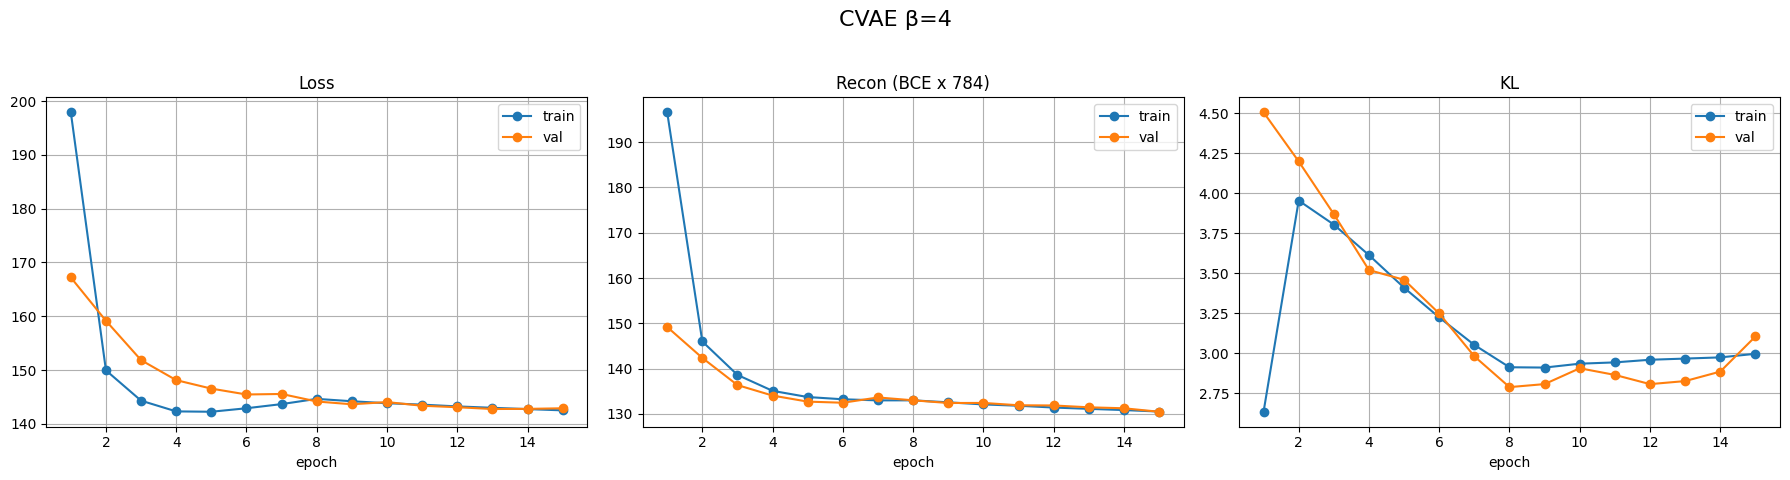

In [9]:
def plot_curves(history, beta):
    """Plots the training and validation loss curves."""
    epochs = range(1, len(history['train_loss']) + 1)

    # Create a figure with 3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'CVAE β={beta}', fontsize=16)

    # Plot 1: Total Loss
    ax1.plot(epochs, history['train_loss'], 'o-', label='train')
    ax1.plot(epochs, history['val_loss'], 'o-', label='val')
    ax1.set_title('Loss')
    ax1.set_xlabel('epoch')
    ax1.legend()
    ax1.grid(True)

    # Plot 2: Reconstruction Loss
    ax2.plot(epochs, history['train_recon'], 'o-', label='train')
    ax2.plot(epochs, history['val_recon'], 'o-', label='val')
    ax2.set_title('Recon (BCE x 784)')
    ax2.set_xlabel('epoch')
    ax2.legend()
    ax2.grid(True)

    # Plot 3: KL Divergence
    ax3.plot(epochs, history['train_kl'], 'o-', label='train')
    ax3.plot(epochs, history['val_kl'], 'o-', label='val')
    ax3.set_title('KL')
    ax3.set_xlabel('epoch')
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Generate the plots for both models
print("Displaying training curves for beta=1")
plot_curves(history_b1, beta=1)

print("\nDisplaying training curves for beta=4")
plot_curves(history_b4, beta=4)

#  Part 2: Reconstructions & Conditional Generation

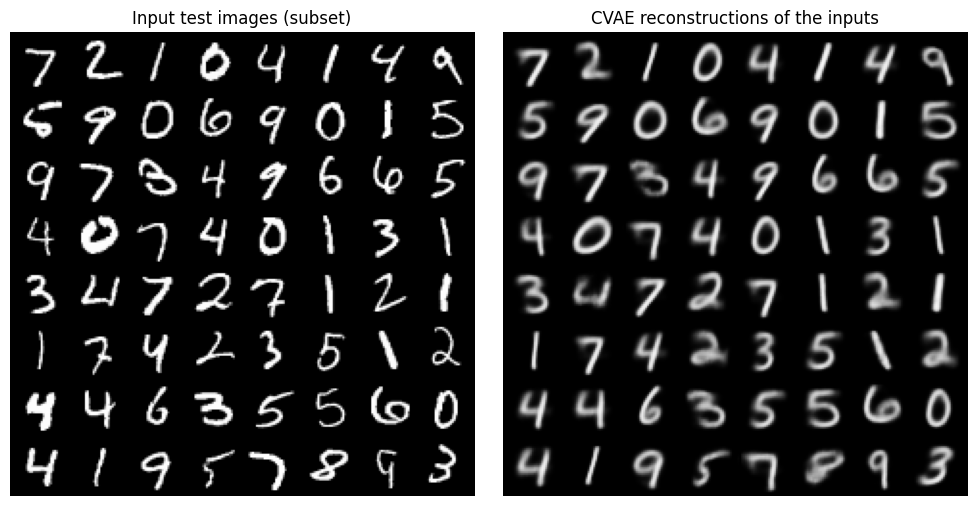

In [10]:
def show_reconstructions(model, loader, device):
  # inputs are train model, data loader and grid for displaying images (original and rescontructed)

  model.eval()

  # one batch of images and their labels
  images, labels = next(iter(loader))
  images, labels = images.to(device), labels.to(device)

  # Only need subset for visualization
  images = images[:64]
  labels = labels[:64]

  with torch.no_grad():
    # get the reconstructed logits
    recon_logits, _, _ = model(images, labels)
    # get the probabilities using the sigmoid function
    recon_images = torch.sigmoid(recon_logits)


  # Plotting
  plt.figure(figsize=(10, 5))

  # original images
  plt.subplot(1, 2, 1)
  plt.title("Input test images (subset)")
  grid_inputs = vutils.make_grid(images.cpu(), nrow=8, padding=2, normalize=False)
  plt.imshow(grid_inputs.permute(1, 2, 0))
  plt.axis('off')

  # reconstructed images
  plt.subplot(1, 2, 2)
  plt.title("CVAE reconstructions of the inputs")
  grid_recons = vutils.make_grid(recon_images.cpu(), nrow=8, padding=2, normalize=False)
  plt.imshow(grid_recons.permute(1, 2, 0))
  plt.axis('off')

  plt.tight_layout()
  plt.show()

# trained model with the beta=1
show_reconstructions(model_b1, val_loader, device)

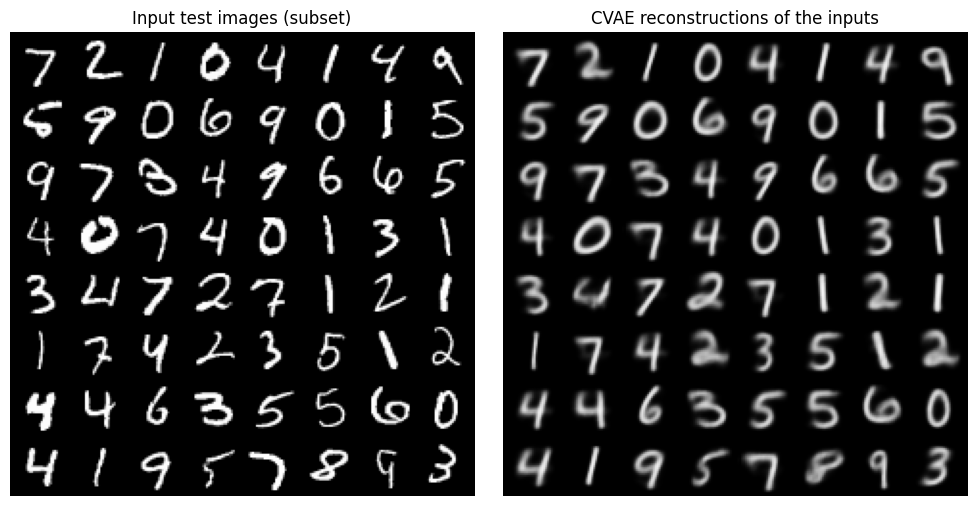

In [11]:
# with beta=2
show_reconstructions(model_b4, val_loader, device)

#  Part 3: Latent Space Visualization

Generating latent space plot for β=1...


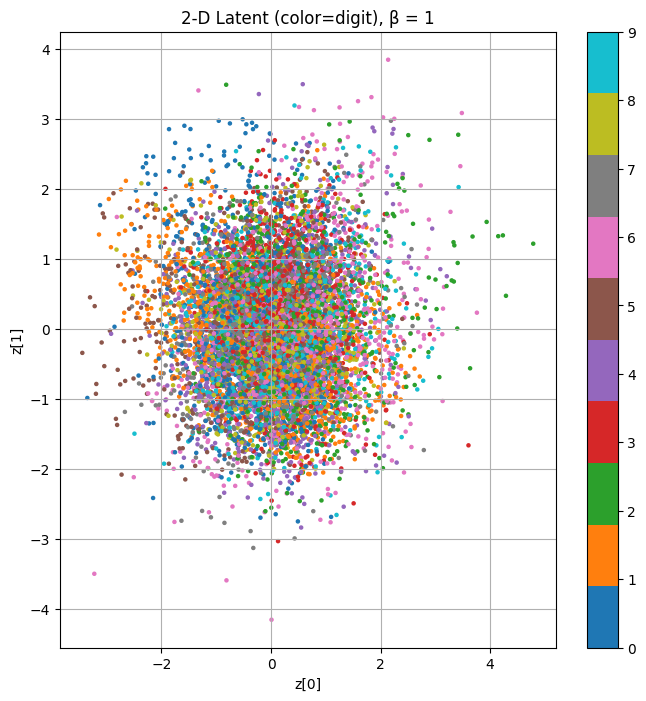


Generating latent space plot for β=4...


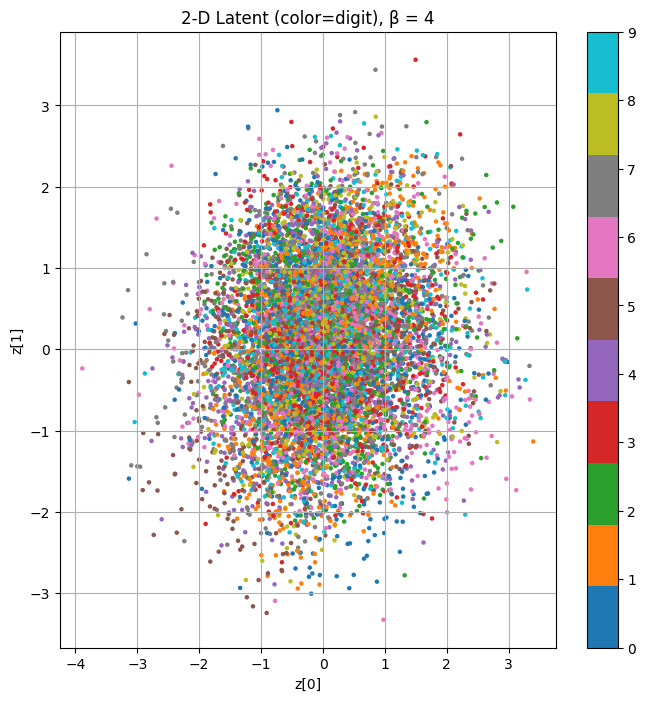

In [12]:
def get_latent_representations(model, loader, device):
    # Encodes the entire dataset to get the latent vectors (mu).

    model.eval()
    latents = []
    labels_list = []

    with torch.no_grad():
        for data, labels in loader:
            data, labels = data.to(device), labels.to(device)
            # We only need the mean (mu) for the scatter plot
            mu, _ = model.encode(data, labels)
            latents.append(mu.cpu())
            labels_list.append(labels.cpu())

    # Concatenate all batches into single tensors
    latents = torch.cat(latents, dim=0).numpy()
    labels_list = torch.cat(labels_list, dim=0).numpy()

    return latents, labels_list

def plot_latent_space(latents, labels, beta):
    #Creates a 2-D scatter plot of the latent vectors, colored by label.

    plt.figure(figsize=(8, 8))
    scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', s=5)
    plt.colorbar(scatter, ticks=range(10))
    plt.title(f'2-D Latent (color=digit), β = {beta}')
    plt.xlabel('z[0]')
    plt.ylabel('z[1]')
    plt.grid(True)
    plt.show()

# Generate and Plot for beta=1
print("Generating latent space plot for β=1...")
latents_b1, labels_b1 = get_latent_representations(model_b1, val_loader, device)
plot_latent_space(latents_b1, labels_b1, beta=1)

# Generate and Plot for beta=4
print("\nGenerating latent space plot for β=4...")
latents_b4, labels_b4 = get_latent_representations(model_b4, val_loader, device)
plot_latent_space(latents_b4, labels_b4, beta=4)

# Comments on Cluster Separation

1- CVAE with β = 1

The distribution is spread out, extending roughly form -3 to +3. Showing the model is using large area of latend space.

The colors are almost completely mixed together. It is very difficult to see any distinct cluster. This indicated that while the modle can reconstruct the digits, its internal map is not well organized by class.




2- CVAE with β = 2

The distribution is spread out in this case too, extending roughly from -2 to +2, means taking smaller area compare to beta=1. So, increaing the beta value is making the KL divergence stronger and forcing the encoder to produce distribution much closer to the standard normal prior (N(0,I)).

The points are not still pefectly separated, the organization is slightly better than beta=1 plot. The model was forced to organize the latent space more efficiently to both satisfy the stronger KL penalty and still be able to reconstruct the images.


# Part 4: Latent Traversals & Manifold

Generating traversals for β=1 model...


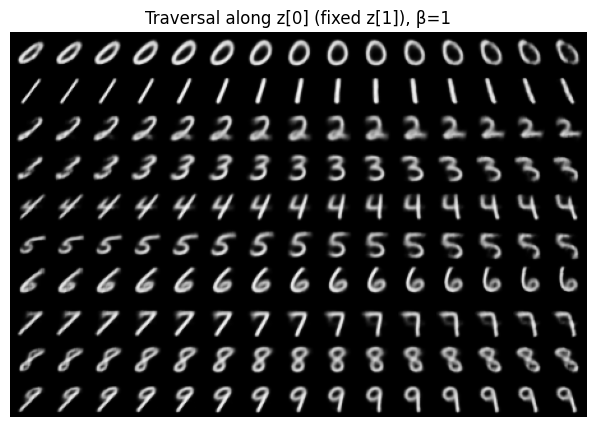

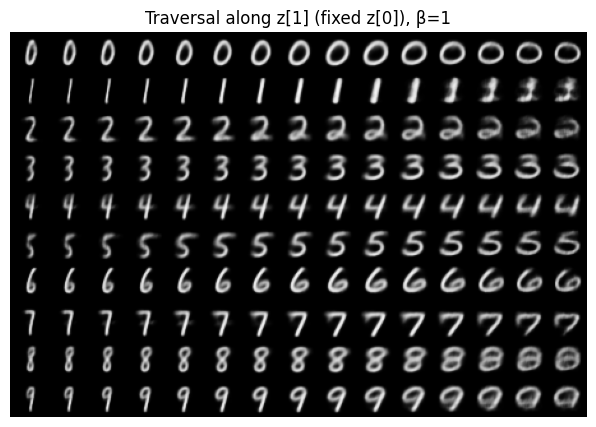


Generating traversals for β=4 model...


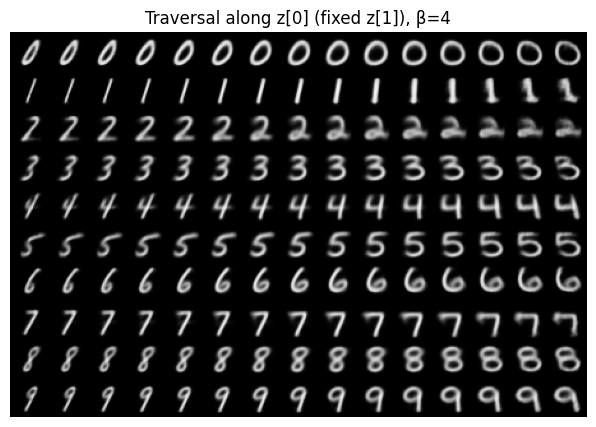

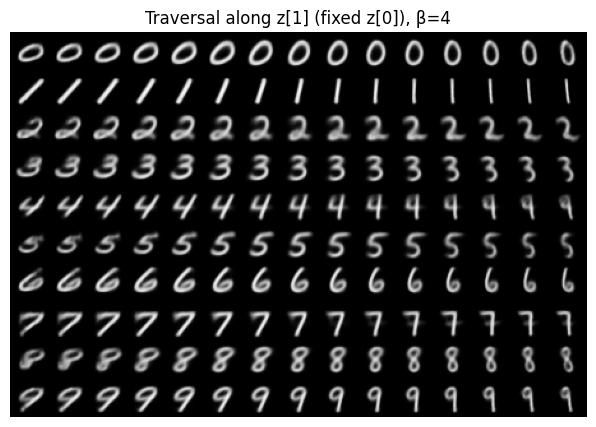

In [15]:
def plot_all_traversals(model, device, num_steps=15):
    """
    Generating and displaying traversal plot:
    1. Traversal along z[0] for all digits.
    2. Traversal along z[1] for all digits.
    """
    model.eval()

    # Create a range of values to sweep across the latent dimensions
    traversal_range = torch.linspace(-3.0, 3.0, steps=num_steps).to(device)

    # 1. Generate images for traversal along z[0] ---
    z_traverse_x = torch.zeros(10 * num_steps, model.latent_dim, device=device)
    y_labels_x = torch.zeros(10 * num_steps, dtype=torch.long, device=device)

    for digit in range(10):
        start_idx = digit * num_steps
        end_idx = (digit + 1) * num_steps

        # Set z[0] to the traversal range and z[1] to 0
        z_traverse_x[start_idx:end_idx, 0] = traversal_range
        y_labels_x[start_idx:end_idx] = digit

    with torch.no_grad():
        generated_x = torch.sigmoid(model.decode(z_traverse_x, y_labels_x))

    #  2. Generate images for traversal along z[1] ---
    z_traverse_y = torch.zeros(10 * num_steps, model.latent_dim, device=device)
    y_labels_y = torch.zeros(10 * num_steps, dtype=torch.long, device=device)

    for digit in range(10):
        start_idx = digit * num_steps
        end_idx = (digit + 1) * num_steps

        # Set z[0] to 0 and z[1] to the traversal range
        z_traverse_y[start_idx:end_idx, 1] = traversal_range
        y_labels_y[start_idx:end_idx] = digit

    with torch.no_grad():
        generated_y = torch.sigmoid(model.decode(z_traverse_y, y_labels_y))

    # Plotting
    beta_val = model.beta if hasattr(model, "beta") else "?"

    # Plot 1: Traversal along z[0]
    grid_x = vutils.make_grid(generated_x.cpu(), nrow=num_steps, padding=2, normalize=False)
    fig1 = plt.figure(figsize=(num_steps * 0.5, 5))
    plt.imshow(grid_x.permute(1, 2, 0))
    plt.title(f'Traversal along z[0] (fixed z[1]), β={beta_val}')
    plt.axis('off')
    plt.show()

    # Plot 2: Traversal along z[1]
    grid_y = vutils.make_grid(generated_y.cpu(), nrow=num_steps, padding=2, normalize=False)
    fig2 = plt.figure(figsize=(num_steps * 0.5, 5))
    plt.imshow(grid_y.permute(1, 2, 0))
    plt.title(f'Traversal along z[1] (fixed z[0]), β={beta_val}')
    plt.axis('off')
    plt.show()


# Generate the two traversal plots for the beta=1 model
print("Generating traversals for β=1 model...")
plot_all_traversals(model_b1, device)

# Generate the two traversal plots for the beta=4 model
print("\nGenerating traversals for β=4 model...")
plot_all_traversals(model_b4, device)

Generating manifold for β=1 model...


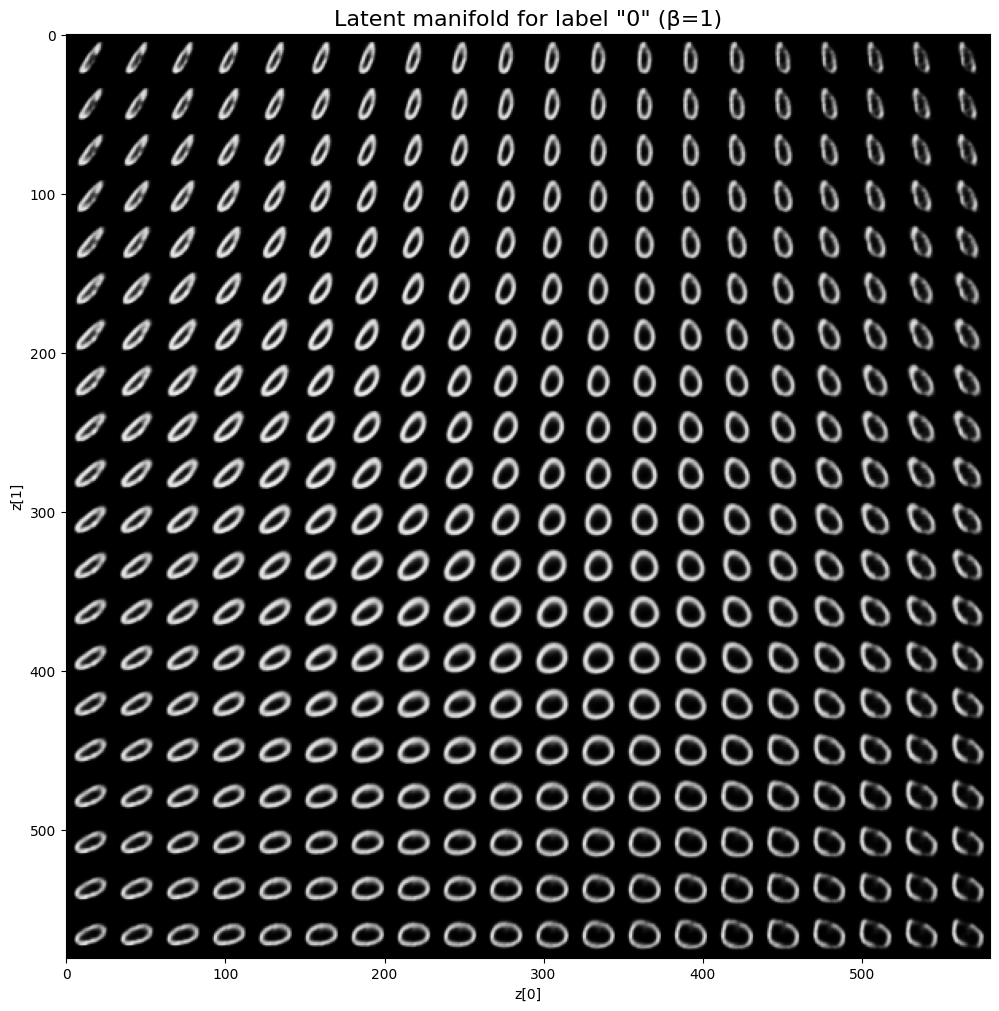


Generating manifold for β=4 model...


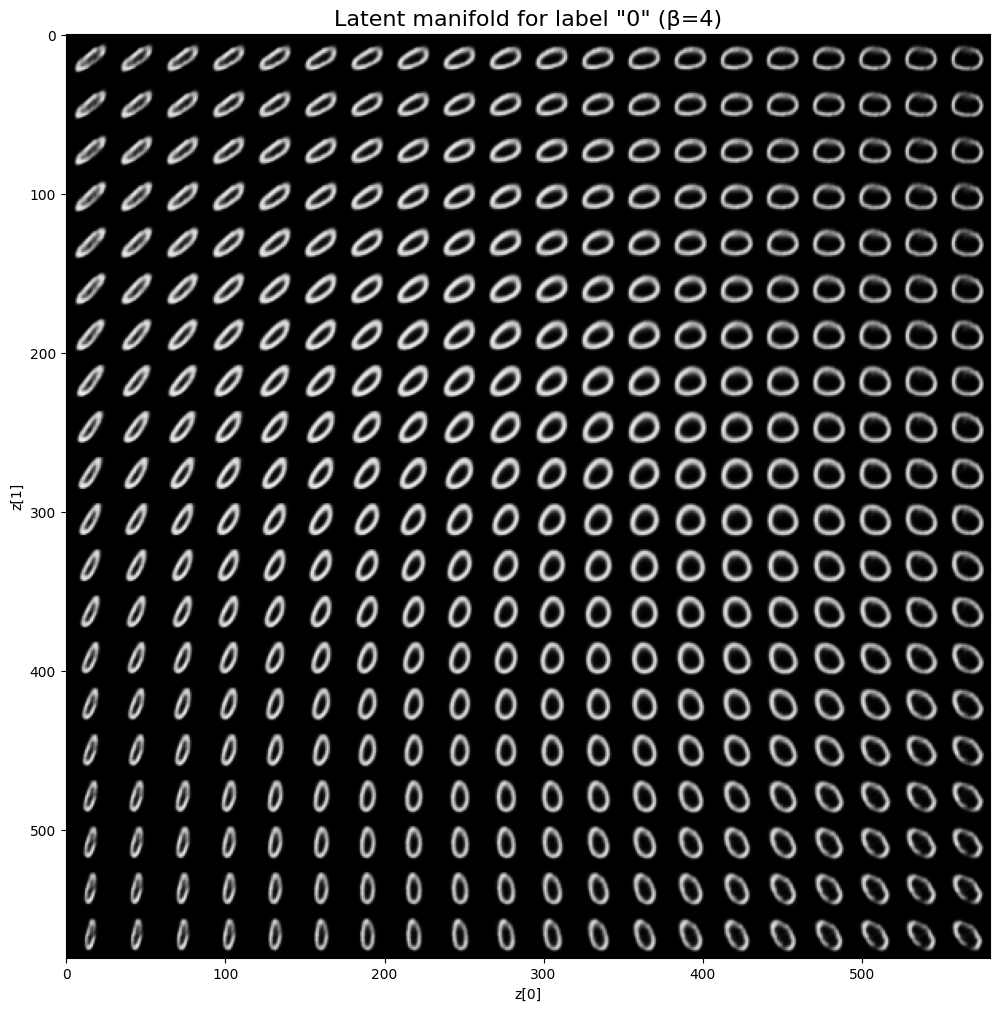

In [14]:
def generate_manifold(model, device, label=0, grid_size=20):
    #Generates a 2D manifold of images for a fixed label.

    model.eval()

    # Create a 2D grid of coordinates in the latent space
    x_range = torch.linspace(-3.0, 3.0, grid_size)
    y_range = torch.linspace(-3.0, 3.0, grid_size)
    grid_x, grid_y = torch.meshgrid(x_range, y_range, indexing='xy')

    # Flatten the grid to create a batch of z vectors
    z_vectors = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1).to(device)

    # Create the corresponding labels (all are the fixed label)
    y_labels = torch.full((grid_size * grid_size,), fill_value=label, dtype=torch.long).to(device)

    with torch.no_grad():
        generated_logits = model.decode(z_vectors, y_labels)
        generated_images = torch.sigmoid(generated_logits)

    plt.figure(figsize=(12, 12))
    grid = vutils.make_grid(generated_images.cpu(), nrow=grid_size, padding=1, normalize=False)
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f'Latent manifold for label "{label}" (β={model.beta if hasattr(model, "beta") else "?"})', fontsize=16)
    plt.xlabel('z[0]')
    plt.ylabel('z[1]')
    plt.show()

model_b1.beta = 1
model_b4.beta = 4

# Generate the manifold for the digit '0' with the beta=1 model
print("Generating manifold for β=1 model...")
generate_manifold(model_b1, device, label=0)

# Generate the manifold for the digit '0' with the beta=4 model
print("\nGenerating manifold for β=4 model...")
generate_manifold(model_b4, device, label=0)